# Linear Regression

In [17]:
import numpy as np
import matplotlib.pyplot as plt
# plt.style.use('./deeplearning.mplstyle')
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression as regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
import statsmodels.api as sm
import sklearn.metrics as metrics #PredictionErrorDisplay

## Generate data using Make Regression

(100, 1) (100,)
---



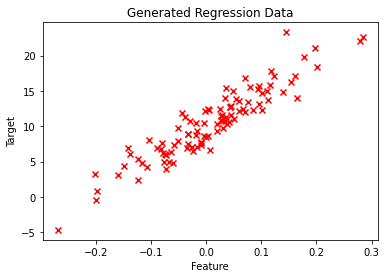

In [9]:
# Generate data
data = regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, bias=10, effective_rank=1, tail_strength=0.2, noise=1.9, shuffle=True, coef=False, random_state=None)

# Set features and target
X = data[0]
y = data[1]

# Check the shape of the taret/features
print(X.shape, y.shape)
print("---\n")

# Plot the data points
plt.scatter(X, y, marker='x', c='r')
# Set the title
plt.title("Generated Regression Data")
# Set the y-axis label
plt.ylabel('Target')
# Set the x-axis label
plt.xlabel('Feature')
plt.show()

In [10]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Print coefficients and intercept of the model
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Coefficients: [45.45654153]
Intercept: 10.146242391366929


In [11]:
# Prediction on test set
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"R-squared score: {r2}")
print(f"Mean Squared Error: {mse}")

R-squared score: 0.8786412393668891
Mean Squared Error: 2.6334315510464856


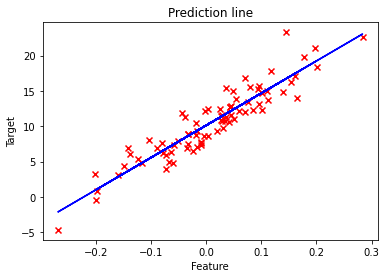

In [12]:
m = model.coef_
b = model.intercept_

y_hat = m*X_train + b

# y_hat


# Plot the data points with prediction line
plt.scatter(X_train, y_train, marker='x', c='r')
# Create prediction line
plt.plot(X_train, y_hat, color='b', linestyle='-', label=f'y = {m}x + {b}')

# Set the title
plt.title("Prediction line")
# Set the y-axis label
plt.ylabel('Target')
# Set the x-axis label
plt.xlabel('Feature')
plt.show()

In [13]:
residuals = y_train - y_hat[0]

print(residuals.shape, y_hat.shape)

# plt.scatter(residuals, y_hat, c='r')
# plt.title("Residual Plot")
# plt.show()

(80,) (80, 1)


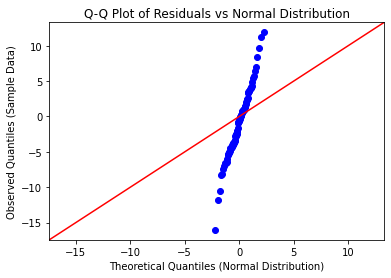

In [14]:
sm.qqplot(residuals, line='45')

plt.title('Q-Q Plot of Residuals vs Normal Distribution')
plt.xlabel('Theoretical Quantiles (Normal Distribution)')
plt.ylabel('Observed Quantiles (Sample Data)')

# 4. Display the plot
plt.show()

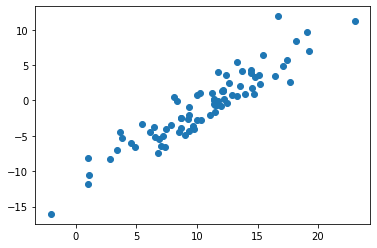

In [18]:
plt.scatter(y_hat, residuals)

(array([ 1.,  2.,  2., 11., 18., 15., 16.,  9.,  3.,  3.]),
 array([-16.03497851, -13.24069115, -10.44640379,  -7.65211643,
         -4.85782906,  -2.0635417 ,   0.73074566,   3.52503302,
          6.31932038,   9.11360774,  11.9078951 ]),
 <a list of 10 Patch objects>)

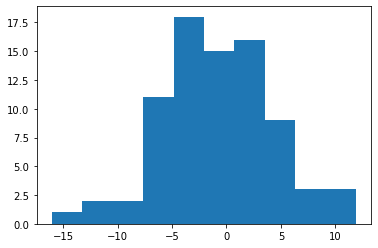

In [22]:
plt.hist(residuals, bins=10)

In [19]:
stats.shapiro(residuals)

ShapiroResult(statistic=0.9893538355827332, pvalue=0.7540535926818848)